In [5]:
import ocha_stratus as stratus
from dotenv import load_dotenv
import geopandas as gpd
import pandas as pd

load_dotenv()

True

In [9]:
# Floodscan raster stats
df_fs = stratus.load_parquet_from_blob(
    "ds-aa-nga-flooding/processed/floodscan/floodscan_hfr_lgas.parquet"
)
# LGA boundaries
gdf_lga_sel = stratus.load_geoparquet_from_blob(
    "ds-aa-nga-flooding/processed/selected_lgas.parquet"
)

In [ ]:
gdf_nga = stratus.codab.load_codab_from_blob("NGA", 0)

# Floodscan cogs 
dates = pd.date_range('2022-10-01', '2022-11-30').strftime('%Y-%m-%d').tolist()
ds_fs = stratus.stack_cogs("floodscan", dates, "prod", gdf_nga)

100%|██████████| 61/61 [00:27<00:00,  2.23it/s]


In [11]:
ds_fs = ds_fs.sel(band=1)

In [12]:
import numpy as np
import matplotlib.pyplot as plt

HA_COLORS = {1: "#E63946", 2: "#F77F00", 3: "#FCBF49", 4: "#06A77D", 5: "#0077B6"}

# Merge pcode-level floodscan stats with HA assignments
df = df_fs.merge(
    gdf_lga_sel[["ADM2_PCODE", "HA_assigned"]],
    left_on="pcode",
    right_on="ADM2_PCODE",
    how="inner",
)

# Daily mean ± std of SFED across LGAs within each HA
df_ha = (
    df.groupby(["HA_assigned", "valid_date"])["mean"]
    .agg(ha_mean="mean", ha_std="std")
    .reset_index()
)

In [ ]:
import calendar

# --- Time series: day-of-year average flooded fraction per HA (±1 SD across LGAs) ---
df_ha["doy"] = df_ha["valid_date"].dt.dayofyear

df_ha_doy = (
    df_ha.groupby(["HA_assigned", "doy"])["ha_mean"]
    .agg(doy_mean="mean", doy_std="std")
    .reset_index()
)

ymax = (df_ha_doy["doy_mean"] + df_ha_doy["doy_std"]).max() * 1.05

# Month tick positions and labels
month_starts = [sum(calendar.monthrange(2001, m)[1] for m in range(1, mo)) + 1 for mo in range(1, 13)]
month_labels = [calendar.month_abbr[m] for m in range(1, 13)]

has = sorted(df_ha_doy["HA_assigned"].unique())
fig, axes = plt.subplots(len(has), 1, figsize=(14, 3 * len(has)), sharex=True, sharey=True)

for ax, ha in zip(axes, has):
    grp = df_ha_doy[df_ha_doy["HA_assigned"] == ha].sort_values("doy")
    color = HA_COLORS.get(int(ha), "#999")

    ax.fill_between(
        grp["doy"],
        (grp["doy_mean"] - grp["doy_std"]).clip(lower=0),
        grp["doy_mean"] + grp["doy_std"],
        color=color, alpha=0.2, linewidth=0,
    )
    ax.plot(grp["doy"], grp["doy_mean"], color=color, linewidth=1.2, alpha=0.9)

    ax.set_ylabel("SFED", fontsize=15)
    ax.set_ylim(0, ymax)
    ax.tick_params(axis="y", labelsize=13)
    ax.set_title(f"HA {int(ha)}", fontsize=15, color=color, fontweight="bold", loc="left")
    ax.spines[["top", "right"]].set_visible(False)

axes[-1].set_xticks(month_starts)
axes[-1].set_xticklabels(month_labels, fontsize=15)
axes[-1].set_xlim(1, 365)
axes[-1].set_xlabel("")

fig.suptitle(
    "Day-of-year average flooded fraction per hydrological area (shading = ±1 SD across LGAs & years)",
    fontsize=15, y=1.01,
)
plt.tight_layout()
plt.savefig("figures/floodscan_ha_doy.png", dpi=200, bbox_inches="tight")

In [ ]:
# --- Pixel map: floodscan SFED for a selected date ---
selected_date = "2022-10-15"  # change to explore

da = ds_fs.sel(date=selected_date)

fig, ax = plt.subplots(figsize=(10, 9))

gdf_nga.plot(ax=ax, facecolor="#f5f5f5", edgecolor="#aaaaaa", linewidth=0.7)

da.plot(
    ax=ax,
    cmap="Blues",
    vmin=0,
    vmax=0.5,
    alpha=0.85,
    add_colorbar=True,
    cbar_kwargs={
        "label": "Flooded fraction (SFED)",
        "orientation": "horizontal",
        "shrink": 0.5,
        "pad": 0.02,
        "anchor": (0.5, 1.0),
    },
)

gdf_lga_sel.plot(ax=ax, facecolor="none", edgecolor="#E63946", linewidth=0.8, zorder=3)

ax.set_title(f"Floodscan SFED — {selected_date}", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(f"figures/floodscan_map_{selected_date}.png", dpi=200, bbox_inches="tight")

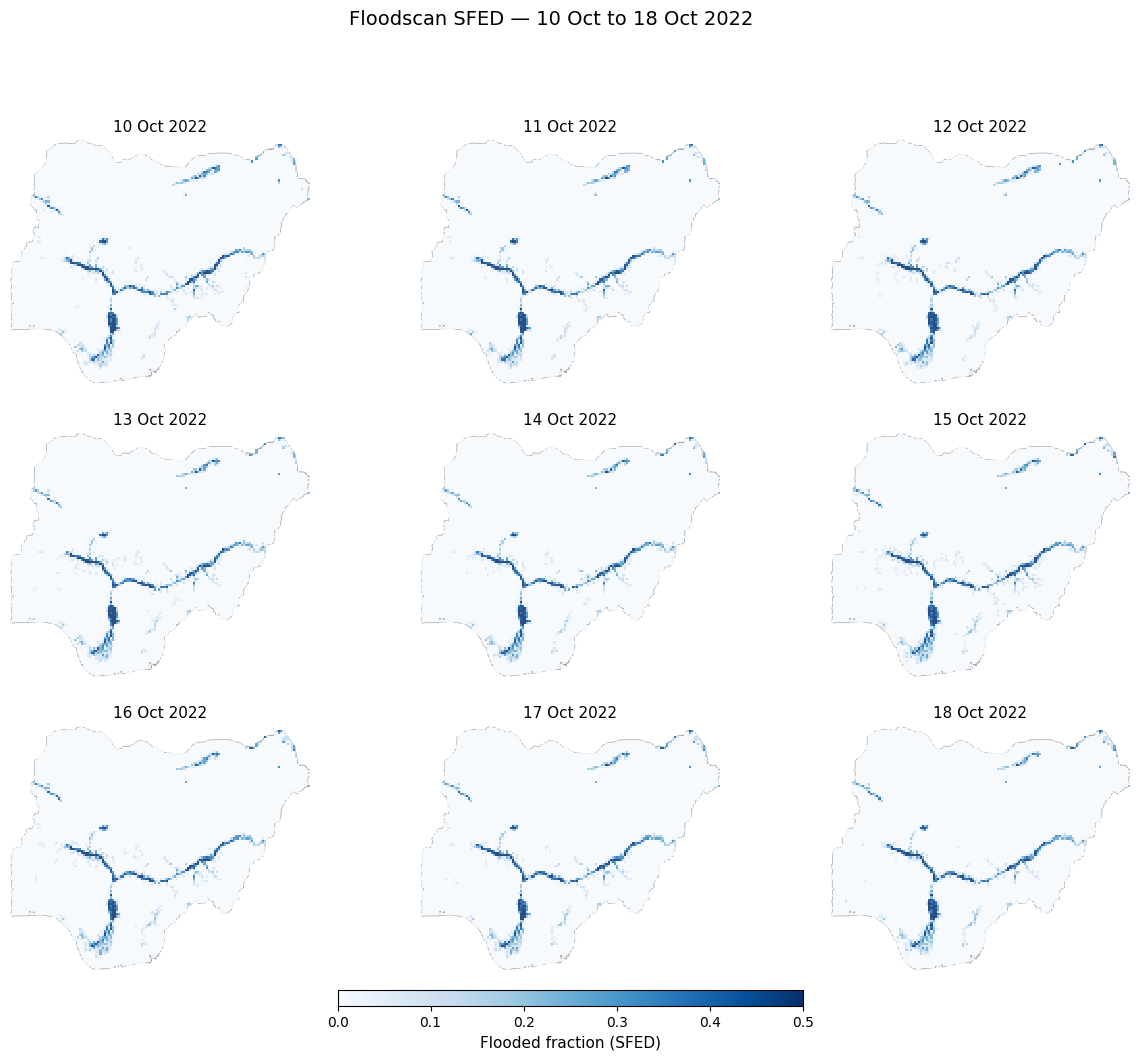

In [ ]:
# --- 3x3 faceted map: floodscan SFED over a 9-day window ---
start_date = "2022-10-10"  # change to explore — generates 9 consecutive days

dates_9 = pd.date_range(start_date, periods=9, freq="D")

# Shared colour scale across all panels
vmin, vmax = 0, 0.5

fig, axes = plt.subplots(3, 3, figsize=(15, 13))

for ax, date in zip(axes.flat, dates_9):
    date_str = date.strftime("%Y-%m-%d")
    da = ds_fs.sel(date=date_str)

    gdf_nga.plot(ax=ax, facecolor="#f5f5f5", edgecolor="#aaaaaa", linewidth=0.5)
    da.plot(
        ax=ax,
        cmap="Blues",
        vmin=vmin,
        vmax=vmax,
        alpha=0.85,
        add_colorbar=False,
    )

    ax.set_title(date.strftime("%d %b %Y"), fontsize=11)
    ax.set_axis_off()

# Shared horizontal colorbar below the grid
import matplotlib.cm as cm
import matplotlib.colors as mcolors
sm = cm.ScalarMappable(cmap="Blues", norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", shrink=0.4, pad=0.02, aspect=30)
cbar.set_label("Flooded fraction (SFED)", fontsize=11)

fig.suptitle(f"Floodscan SFED — {dates_9[0].strftime('%d %b')} to {dates_9[-1].strftime('%d %b %Y')}", fontsize=14)
plt.savefig(f"figures/floodscan_grid_{start_date}.png", dpi=200, bbox_inches="tight")